# Superhero Review Sentiment vs. Time Since Release

This notebook uses `marvel_movie_reviews_lexicon_sentiment.csv` as input and producing summary statistics (Spearman correlation, Kruskal–Wallis test) plus six figures saved to `./figures/`. It requires Python 3.10+ with pandas, numpy, matplotlib, seaborn, scipy, and statsmodels, and should be run top to bottom.



In [7]:
%matplotlib inline


import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

CSV_PATH = "/Users/haero/DS4002/DS-4002-Project-1/OUTPUT/marvel_movie_reviews_lexicon_sentiment.csv"
OUT_DIR = "figures"  # figures are also saved here
os.makedirs(OUT_DIR, exist_ok=True)
sns.set_theme(style="whitegrid")


## Load and prepare data

In [8]:
df = pd.read_csv(CSV_PATH)
df["years"] = df["days_since_release"] / 365.25

# Time windows for grouped comparisons
bins = [-1, 30, 365, 1825, np.inf]
labels = ["≤1 month", "1 mo–1 yr", "1–5 yrs", "5+ yrs"]
df["window"] = pd.cut(df["days_since_release"], bins=bins,
                      labels=labels, include_lowest=True)


## Summary statistics

In [9]:
rho, p = stats.spearmanr(df["days_since_release"], df["polarity_score"])
print(f"Overall Spearman rho = {rho:.3f}, p = {p:.3f}  (n = {len(df)})")

long_reviews = df[df["total_word_count"] >= 10]
rho_f, p_f = stats.spearmanr(long_reviews["days_since_release"],
                             long_reviews["polarity_score"])
print(f"Reviews with ≥10 words: rho = {rho_f:.3f}, p = {p_f:.3f}  "
      f"(n = {len(long_reviews)})")

print("\nPolarity by timing window:")
print(df.groupby("window", observed=True)["polarity_score"]
        .agg(["count", "mean", "median"]).round(4))

groups = [g["polarity_score"] for _, g in df.groupby("window", observed=True)]
h, p_kw = stats.kruskal(*groups)
print(f"\nKruskal–Wallis across windows: H = {h:.2f}, p = {p_kw:.4f}")

print("\nBy franchise:")
print(df.groupby("franchise").agg(
    n=("polarity_score", "size"),
    mean_polarity=("polarity_score", "mean"),
    median_days=("days_since_release", "median"),
).round(4))

print(f"\nReviews posted before release (days < 0): "
      f"{(df['days_since_release'] < 0).sum()}")
print(f"Reviews with polarity exactly 0: {(df['polarity_score'] == 0).sum()}")


Overall Spearman rho = -0.024, p = 0.596  (n = 486)
Reviews with ≥10 words: rho = 0.014, p = 0.770  (n = 467)

Polarity by timing window:
           count    mean  median
window                          
≤1 month      49  0.0731  0.0174
1 mo–1 yr     94  0.0470  0.0298
1–5 yrs      142  0.0796  0.0546
5+ yrs       201  0.0399  0.0333

Kruskal–Wallis across windows: H = 13.99, p = 0.0029

By franchise:
                   n  mean_polarity  median_days
franchise                                       
Avengers         173         0.0729        828.0
Captain America   47         0.0562       1363.0
Iron Man          34         0.0154       3708.5
Spider-Man       232         0.0497        971.0

Reviews posted before release (days < 0): 2
Reviews with polarity exactly 0: 58


## Graph 1: Scatter + LOWESS trend

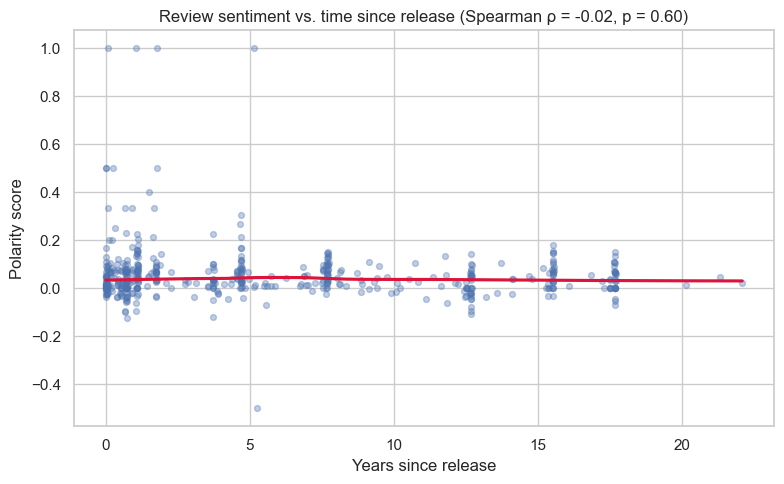

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=df, x="years", y="polarity_score", lowess=True,
            scatter_kws=dict(alpha=0.35, s=18),
            line_kws=dict(color="crimson"), ax=ax)
ax.set(xlabel="Years since release", ylabel="Polarity score",
       title=f"Review sentiment vs. time since release "
             f"(Spearman ρ = {rho:.2f}, p = {p:.2f})")
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/1_scatter_lowess.png", dpi=150)


plt.show()


## Graph 2: Boxplots by timing window

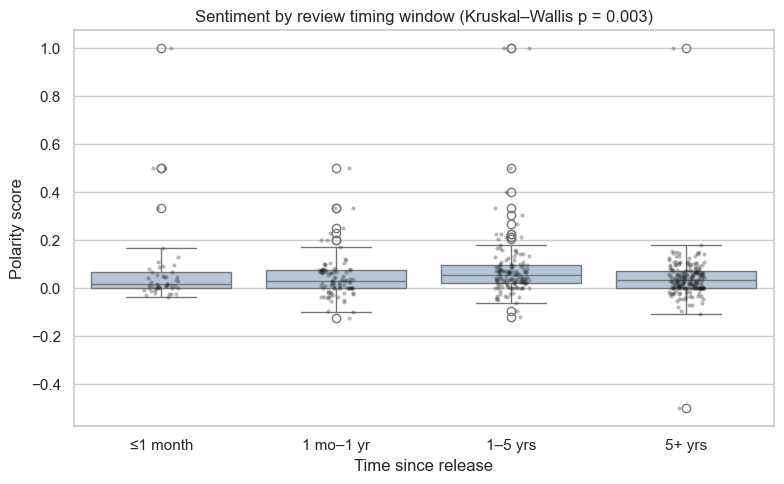

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="window", y="polarity_score",
            color="lightsteelblue", ax=ax)
sns.stripplot(data=df, x="window", y="polarity_score",
              color="k", alpha=0.3, size=3, ax=ax)
ax.set(xlabel="Time since release", ylabel="Polarity score",
       title=f"Sentiment by review timing window "
             f"(Kruskal–Wallis p = {p_kw:.3f})")
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/2_box_windows.png", dpi=150)


plt.show()


## Graph 3: Faceted by franchise

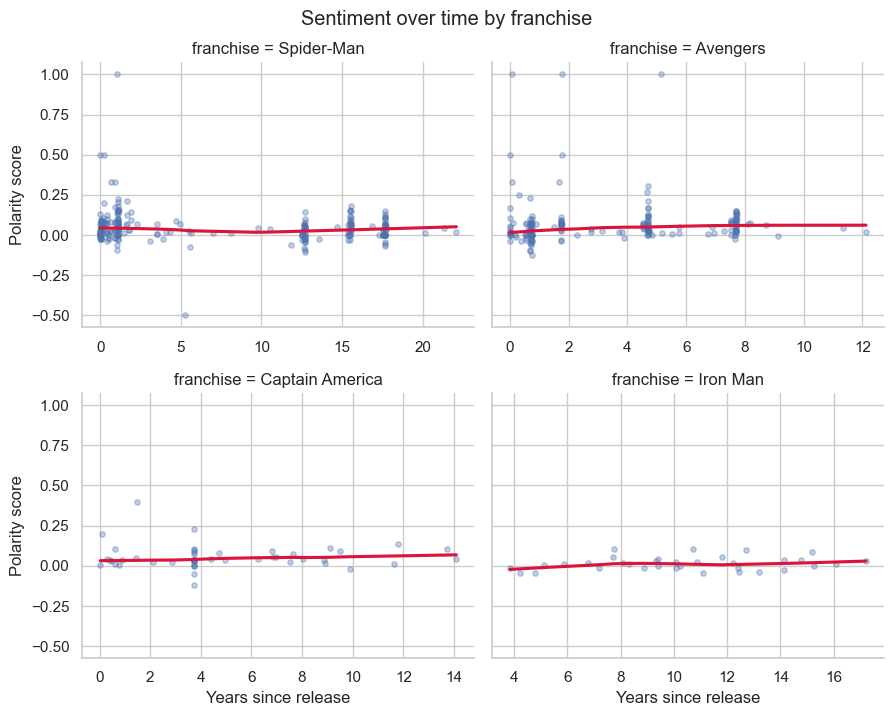

In [12]:
g = sns.lmplot(data=df, x="years", y="polarity_score", col="franchise",
               col_wrap=2, lowess=True, height=3.5, aspect=1.3,
               scatter_kws=dict(alpha=0.35, s=15),
               line_kws=dict(color="crimson"),
               facet_kws=dict(sharex=False))
g.set_axis_labels("Years since release", "Polarity score")
g.fig.suptitle("Sentiment over time by franchise", y=1.02)
g.savefig(f"{OUT_DIR}/3_by_franchise.png", dpi=150)


plt.show()


## Graph 4: Within-movie correlations (movies with ≥8 reviews)

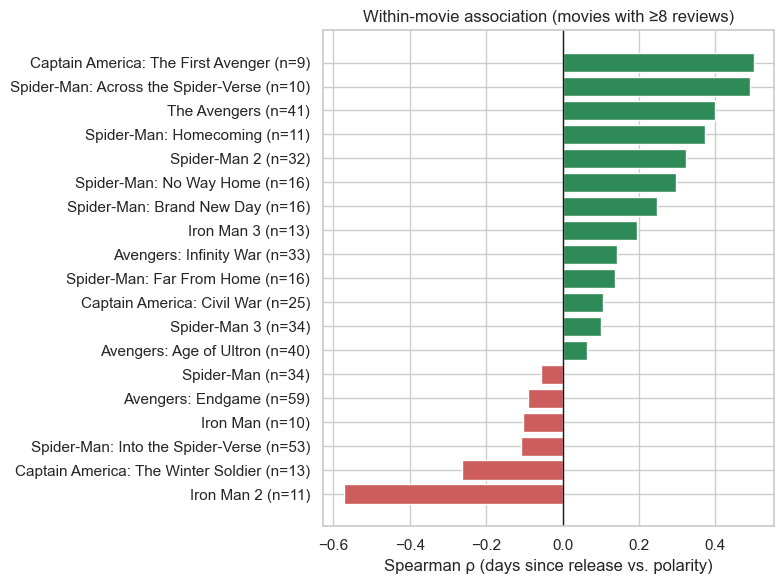

In [13]:
MIN_REVIEWS = 8
rows = []
for movie, grp in df.groupby("movie"):
    if len(grp) >= MIN_REVIEWS:
        r, _ = stats.spearmanr(grp["days_since_release"], grp["polarity_score"])
        rows.append((movie, r, len(grp)))
per_movie = (pd.DataFrame(rows, columns=["movie", "rho", "n"])
               .dropna().sort_values("rho"))

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(per_movie["movie"] + " (n=" + per_movie["n"].astype(str) + ")",
        per_movie["rho"],
        color=np.where(per_movie["rho"] > 0, "seagreen", "indianred"))
ax.axvline(0, color="k", lw=1)
ax.set(xlabel="Spearman ρ (days since release vs. polarity)",
       title=f"Within-movie association (movies with ≥{MIN_REVIEWS} reviews)")
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/4_per_movie_rho.png", dpi=150)


plt.show()


## Graph 5: Distribution of review timing

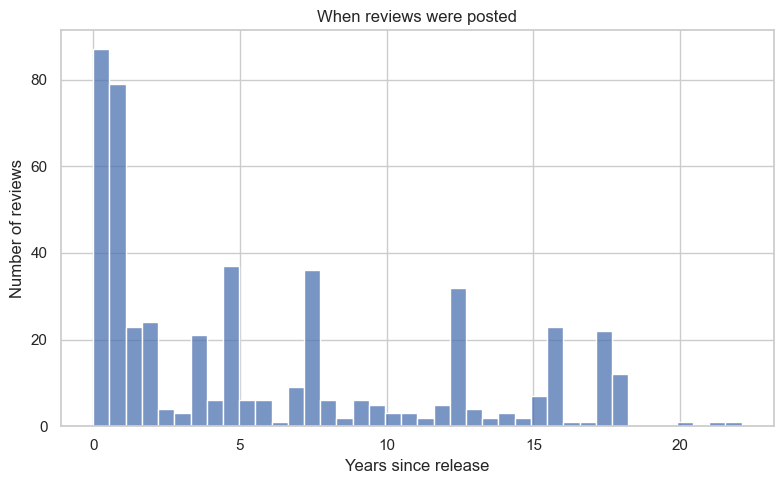

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["years"], bins=40, ax=ax)
ax.set(xlabel="Years since release", ylabel="Number of reviews",
       title="When reviews were posted")
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/5_timing_hist.png", dpi=150)


plt.show()


## Graph 6: Positive vs. negative word rate by window


Saved 6 figures to ./figures/


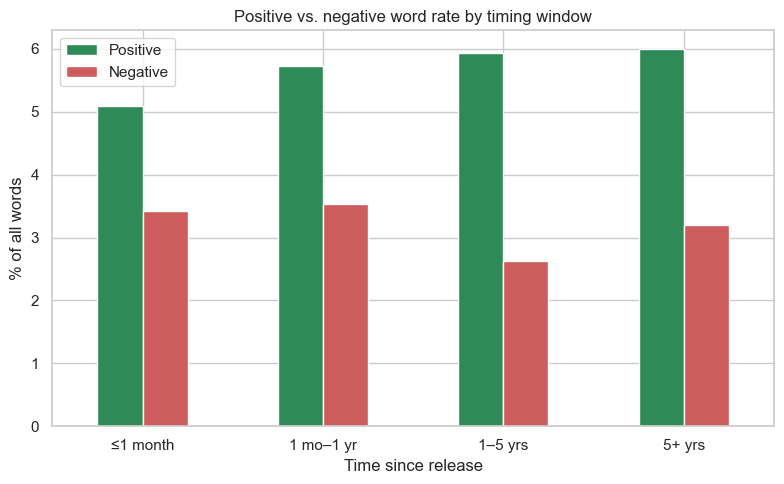

In [15]:
totals = df.groupby("window", observed=True)[
    ["positive_word_count", "negative_word_count", "total_word_count"]].sum()
rates = (totals[["positive_word_count", "negative_word_count"]]
         .div(totals["total_word_count"], axis=0) * 100)

fig, ax = plt.subplots(figsize=(8, 5))
rates.plot(kind="bar", color=["seagreen", "indianred"], ax=ax)
ax.set(xlabel="Time since release", ylabel="% of all words",
       title="Positive vs. negative word rate by timing window")
ax.legend(["Positive", "Negative"])
plt.xticks(rotation=0)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/6_pos_neg_rate.png", dpi=150)

print(f"\nSaved 6 figures to ./{OUT_DIR}/")

plt.show()
